In [ ]:
# Model architecture = XLM-RoBertaab
# raw text 
# learning rate = 2e-5 , train batch size nd eval batch size = 32 , epochs = 7 , tokenizer max length = 256

In [1]:
import pandas as pd
import numpy as np


df=pd.read_csv('data (1).csv')
test=pd.read_csv('test_file.csv')
import re

# Emoji pattern (Unicode ranges)
emoji_pattern = re.compile("["
    u"\U0001F600-\U0001F64F"  # emoticons
    u"\U0001F300-\U0001F5FF"  # symbols & pictographs
    u"\U0001F680-\U0001F6FF"  # transport & map symbols
    u"\U0001F1E0-\U0001F1FF"  # flags
    u"\U00002702-\U000027B0"
    u"\U000024C2-\U0001F251"
    "]+", flags=re.UNICODE)

# Persian characters + basic Persian numbers and punctuation
persian_pattern = re.compile(r'[^\u0600-\u06FF\s\u06F0-\u06F9.,؟!،]')

# Function to clean one string
def clean_farsi_text(text):
    text = str(text)
    text = emoji_pattern.sub('', text)            # remove emojis
    text = persian_pattern.sub('', text)          # remove non-Farsi characters
    text = re.sub(r'\s+', ' ', text).strip()      # remove extra spaces
    return text

# Apply to DataFrame
df['text'] = df['text'].apply(clean_farsi_text)


df = df.dropna(subset=['label'])


df['label_encoded'] = df['label'].astype('category').cat.codes
label2id = dict(enumerate(df['label'].astype('category').cat.categories))
id2label = {v: k for k, v in label2id.items()}

df.head()

,text,label,POS_Tags,POS_Encoded,label_encoded
0,خیلی ناراحت شدم وقتی خبر بدی شنیدم .,sadness,"['ADV', 'ADJ', 'VERB', 'NOUN', 'NOUN', 'ADJ', ...","[2, 0, 14, 7, 7, 0, 14, 7, 12]",5
1,یک فرشته به خواب یکنفر میاد و بهش میگه خدا گفت...,neutral,"['NUM', 'NOUN', 'ADP', 'NOUN', 'NOUN', 'VERB',...","[8, 7, 1, 7, 7, 14, 4, 1, 10, 14, 7, 14, 7, 14...",4
2,ترسیدم چون صدای عجیبی شنیدم .,fear,"['VERB', 'SCONJ', 'NOUN', 'ADJ', 'VERB', 'NOUN...","[14, 13, 7, 0, 14, 7, 12]",2
3,اونقدر حواسمون بود که بقیه ناراحت نشن که الان ...,sadness,"['NOUN', 'ADJ', 'AUX', 'SCONJ', 'NOUN', 'ADJ',...","[7, 0, 3, 13, 7, 0, 14, 13, 7, 10, 7, 14, 1, 8...",5
4,خیلی راحته که ... کدوم جالش..,neutral,"['ADV', 'ADJ', 'SCONJ', 'PUNCT', 'PUNCT', 'PUN...","[2, 0, 13, 12, 12, 12, 7, 7, 10, 12, 12]",4


In [2]:

file_path='test_file.csv'
test=pd.read_csv(file_path)
label_mapping = {
    'HAPPY':'happiness',     
    'SAD':'sadness',      
    'OTHER':'neutral',      
    'ANGRY':'anger',       
    'SURPRISE':'surprize',
    'HATE':'disgust',        
    'FEAR':'fear',        
}

test['label']=test['label'].map(label_mapping)
test=test.dropna(subset=['text'])
test=test.dropna(subset=['label'])
test.head()

,text,label
0,اين شايد اولين عزاى عمومى واقعى است كه ياد دار...,sadness
1,دیشب بعد از ارسال تویت مربوط به آثار باستانی ت...,happiness
2,کدوم شعبه پول نداده، بگو الان برات آمار دقیق ...,neutral
3,امروز وسط یه بحث با بابا مامانم گفتم آدم باید ...,happiness
4,امشب گفت نامزدی دوستش که ادم روشنفکری است بهم ...,sadness


In [3]:
# Add a token to separate sentence from POS
df["combined_text"] = df["text"] 

from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["text"].tolist(),
    df["label_encoded"].tolist(),
    test_size=0.1,
    random_state=42
)

!pip install sentencepiece
from transformers import XLMRobertaTokenizer

tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-large")
max_length = 256  # You can adjust based on your data
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=max_length)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=max_length)

import torch

class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = EmotionDataset(train_encodings, train_labels)
val_dataset = EmotionDataset(val_encodings, val_labels)


from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(pred):
    logits, labels = pred
    predictions = logits.argmax(axis=-1)

    acc = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average='macro')

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
    }

from transformers import XLMRobertaForSequenceClassification

num_labels = df["label_encoded"].nunique()

model = XLMRobertaForSequenceClassification.from_pretrained(
    "xlm-roberta-large",
    num_labels=num_labels
)

!pip install 'accelerate>=0.26.0'
!pip install transformers[torch]
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=7,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
)

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()
metrics = trainer.evaluate()
print("Macro F1 score:", metrics["eval_macro_f1"])


trainer.save_model("./emotion_model_text1")
tokenizer.save_pretrained("./emotion_model_text1")




2025-10-28 15:00:51.165855: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-28 15:00:51.184636: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-28 15:00:51.190345: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-28 15:00:51.206496: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Some weights of XLMRobertaForSequenceCl

/tmp/ipykernel_26458/3356768248.py:82: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.315000,1.311170,0.505844,0.534094
2,1.308900,1.320514,0.505038,0.533146
3,1.301400,1.314230,0.505038,0.533146
4,1.315100,1.312853,0.504837,0.532996
5,1.303100,1.314307,0.504837,0.533094
6,1.295300,1.267266,0.527811,0.559764
7,1.227100,1.238192,0.535268,0.566008


Macro F1 score: 0.5660075017305287


('./emotion_model_text1/tokenizer_config.json',
 './emotion_model_text1/special_tokens_map.json',
 './emotion_model_text1/sentencepiece.bpe.model',
 './emotion_model_text1/added_tokens.json')

In [4]:
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification
import torch

model_path = "./emotion_model_text1"

tokenizer = XLMRobertaTokenizer.from_pretrained(model_path)
model = XLMRobertaForSequenceClassification.from_pretrained(model_path)
model.eval()

# test['label_encoded'] = test['label'].astype('category').cat.codes
# label2id = dict(enumerate(df['label'].astype('category').cat.categories))
# id2label = {v: k for k, v in label2id.items()}


label2id = {label: idx for idx, label in enumerate(df["label"].astype("category").cat.categories)}
id2label = {v: k for k, v in label2id.items()}
test["label_encoded"] = test["label"].map(label2id)

#new one
from torch.utils.data import Dataset
import torch

class EmotionDatasetTextOnly(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df["text"].astype(str).tolist()  
        self.labels = df["label_encoded"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label)
        }

    def __len__(self):
        return len(self.labels)


import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score

# ✅ Auto-detect device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔍 Using device: {device}")

# ✅ Move model to the correct device
model = model.to(device)
model.eval()

# ✅ Dataset without POS tag version (use the correct one for you)
test_dataset = EmotionDatasetTextOnly(test, tokenizer)  # or EmotionTestDatasetWithPOS if you're using POS

# ✅ DataLoader
test_loader = DataLoader(test_dataset, batch_size=16)

# ✅ Storage for predictions and labels
all_preds = []
all_labels = []

# ✅ Evaluation loop
for batch in test_loader:
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

# ✅ Metrics
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")

print(f"\n✅ Test Accuracy: {acc:.4f}")
print(f"✅ Test Macro F1 Score: {f1:.4f}")


🔍 Using device: cuda

✅ Test Accuracy: 0.4622
✅ Test Macro F1 Score: 0.4198



✅ Test Accuracy: 0.4622
✅ Macro F1-score: 0.4198

📊 Classification Report:
              precision    recall  f1-score   support

       anger       0.47      0.66      0.55       154
     disgust       0.00      0.00      0.00        65
        fear       0.70      0.81      0.75        57
   happiness       0.89      0.23      0.36       275
     neutral       0.27      0.84      0.41       193
     sadness       0.79      0.53      0.64       262
    surprize       0.65      0.14      0.23       145

    accuracy                           0.46      1151
   macro avg       0.54      0.46      0.42      1151
weighted avg       0.62      0.46      0.44      1151



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


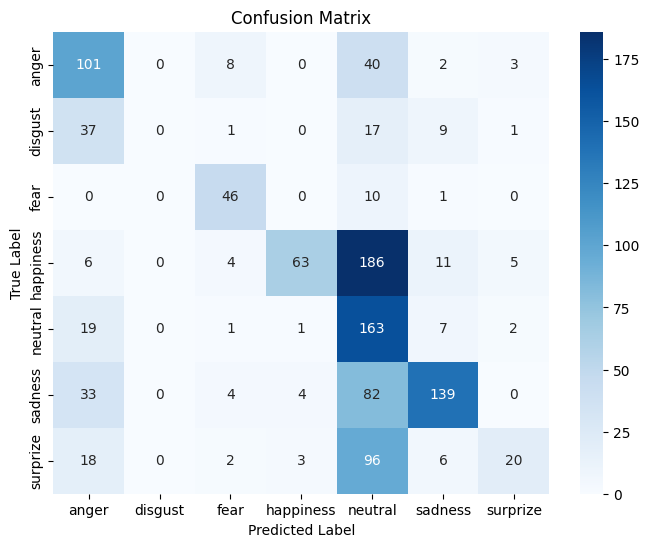

In [6]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ✅ Metrics
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")

print(f"\n✅ Test Accuracy: {acc:.4f}")
print(f"✅ Macro F1-score: {f1:.4f}")

# ✅ Classification report
print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=list(label2id.keys())))

# ✅ Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(cm, index=list(label2id.keys()), columns=list(label2id.keys()))

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


In [9]:
# Iteration 2
# Add a token to separate sentence from POS
df["combined_text"] = df["text"] 

from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["text"].tolist(),
    df["label_encoded"].tolist(),
    test_size=0.1,
    random_state=42
)

!pip install sentencepiece
from transformers import XLMRobertaTokenizer

tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-large")
max_length = 128  # You can adjust based on your data
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=max_length)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=max_length)

import torch

class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = EmotionDataset(train_encodings, train_labels)
val_dataset = EmotionDataset(val_encodings, val_labels)


from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(pred):
    logits, labels = pred
    predictions = logits.argmax(axis=-1)

    acc = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average='macro')

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
    }

from transformers import XLMRobertaForSequenceClassification

num_labels = df["label_encoded"].nunique()

model = XLMRobertaForSequenceClassification.from_pretrained(
    "xlm-roberta-large",
    num_labels=num_labels
)

!pip install 'accelerate>=0.26.0'
!pip install transformers[torch]
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=7,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
)

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()
metrics = trainer.evaluate()
print("Macro F1 score:", metrics["eval_macro_f1"])


trainer.save_model("./emotion_model_text2")
tokenizer.save_pretrained("./emotion_model_text2")




Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


/tmp/ipykernel_26458/4084692406.py:82: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.313600,1.257578,0.532044,0.561478
2,1.240300,1.227386,0.541717,0.566999
3,1.189200,1.204364,0.549375,0.579600
4,1.159800,1.231564,0.543934,0.572091
5,1.091800,1.282922,0.531842,0.557244
6,1.025100,1.317132,0.534663,0.559168
7,0.970300,1.378726,0.528214,0.552840


Macro F1 score: 0.5796004801204812


('./emotion_model_text2/tokenizer_config.json',
 './emotion_model_text2/special_tokens_map.json',
 './emotion_model_text2/sentencepiece.bpe.model',
 './emotion_model_text2/added_tokens.json')

In [10]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score
from transformers import XLMRobertaForSequenceClassification, XLMRobertaTokenizer

# ✅ Auto-detect device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Load fine-tuned model and tokenizer
model_path = "./emotion_model_text2"

tokenizer = XLMRobertaTokenizer.from_pretrained(model_path)
model = XLMRobertaForSequenceClassification.from_pretrained(model_path)

# ✅ Move model to the correct device
model = model.to(device)
model.eval()

# ✅ Dataset without POS tag version (use the correct one for you)
test_dataset = EmotionDatasetTextOnly(test, tokenizer)  

# ✅ DataLoader
test_loader = DataLoader(test_dataset, batch_size=16)

# ✅ Storage for predictions and labels
all_preds = []
all_labels = []

# ✅ Evaluation loop
for batch in test_loader:
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

# ✅ Metrics
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")

print(f"\n✅ Test Accuracy: {acc:.4f}")
print(f"✅ Test Macro F1 Score: {f1:.4f}")



✅ Test Accuracy: 0.5569
✅ Test Macro F1 Score: 0.4989



✅ Test Accuracy: 0.5569
✅ Macro F1-score: 0.4989

📊 Classification Report:
              precision    recall  f1-score   support

       anger       0.55      0.60      0.57       154
     disgust       0.00      0.00      0.00        65
        fear       0.74      0.74      0.74        57
   happiness       0.89      0.35      0.51       275
     neutral       0.34      0.83      0.48       193
     sadness       0.72      0.78      0.75       262
    surprize       0.78      0.32      0.45       145

    accuracy                           0.56      1151
   macro avg       0.57      0.52      0.50      1151
weighted avg       0.64      0.56      0.54      1151



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


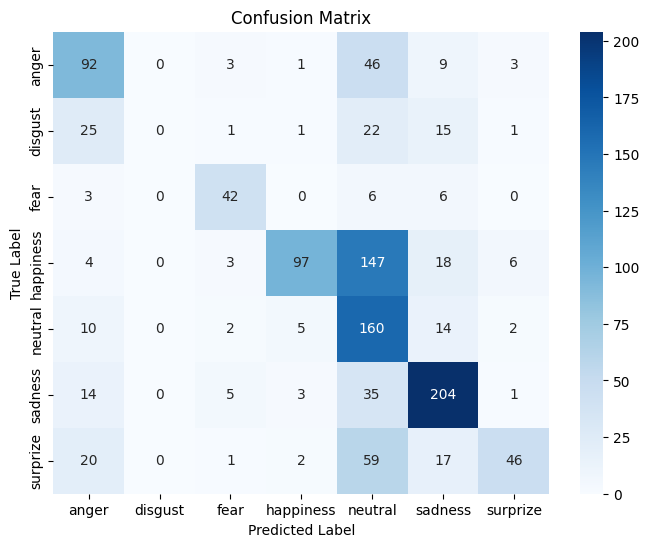

In [11]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ✅ Metrics
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")

print(f"\n✅ Test Accuracy: {acc:.4f}")
print(f"✅ Macro F1-score: {f1:.4f}")

# ✅ Classification report
print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=list(label2id.keys())))

# ✅ Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(cm, index=list(label2id.keys()), columns=list(label2id.keys()))

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


In [12]:
# # ===========================================
# # 1️⃣ Imports
# # ===========================================
# import pandas as pd
# import numpy as np
# import re
# import torch
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
# from transformers import (
#     AutoTokenizer,
#     XLMRobertaForSequenceClassification,
#     TrainingArguments,
#     Trainer
# )

# # ===========================================
# # 2️⃣ Load Data
# # ===========================================
# df = pd.read_csv("data (1).csv")


# # ===========================================
# # 3️⃣ Text Cleaning & Normalization (for Farsi)
# # ===========================================
# emoji_pattern = re.compile("["
#     u"\U0001F600-\U0001F64F"  # emoticons
#     u"\U0001F300-\U0001F5FF"  # symbols & pictographs
#     u"\U0001F680-\U0001F6FF"  # transport & map symbols
#     u"\U0001F1E0-\U0001F1FF"  # flags
#     u"\U00002702-\U000027B0"
#     u"\U000024C2-\U0001F251"
#     "]+", flags=re.UNICODE)

# persian_pattern = re.compile(r'[^\u0600-\u06FF\s\u06F0-\u06F9.,؟!،]')

# def clean_farsi_text(text):
#     text = str(text)
#     text = emoji_pattern.sub('', text)
#     text = persian_pattern.sub('', text)
#     text = re.sub(r'\s+', ' ', text).strip()
#     # Normalize "yeh" and "kaf" forms
#     text = re.sub("[ي]", "ی", text)
#     text = re.sub("[ك]", "ک", text)
#     return text

# df["text"] = df["text"].apply(clean_farsi_text)
# df = df.dropna(subset=["label"])

# # ===========================================
# # 4️⃣ Encode Labels
# # ===========================================
# df["label_encoded"] = df["label"].astype("category").cat.codes
# label2id = dict(enumerate(df["label"].astype("category").cat.categories))
# id2label = {v: k for k, v in label2id.items()}
# num_labels = df["label_encoded"].nunique()

# Iteration 3


# ===========================================
# 5️⃣ Train / Validation Split
# ===========================================
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["text"].tolist(),
    df["label_encoded"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["label_encoded"]
)

# ===========================================
# 6️⃣ Tokenization
# ===========================================
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-large", use_fast=True)
max_length = 128  # preserve more context

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=max_length)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=max_length)

# ===========================================
# 7️⃣ Torch Dataset
# ===========================================
class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = EmotionDataset(train_encodings, train_labels)
val_dataset = EmotionDataset(val_encodings, val_labels)

# ===========================================
# 8️⃣ Metric Function
# ===========================================
def compute_metrics(pred):
    logits, labels = pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average="macro")
    return {"accuracy": acc, "macro_f1": macro_f1}

# ===========================================
# 9️⃣ Load Model
# ===========================================
model = XLMRobertaForSequenceClassification.from_pretrained(
    "xlm-roberta-large",
    num_labels=num_labels
)

# ===========================================
# 🔟 Training Configuration
# ===========================================
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,               # smaller LR improves convergence
    per_device_train_batch_size=64,    # small batch for stability
    per_device_eval_batch_size=644,
    gradient_accumulation_steps=4,    # effective batch = 32
    num_train_epochs=8,               # longer fine-tuning
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    fp16=True,                        # mixed precision for speed
)

# ===========================================
# 1️⃣1️⃣ Trainer
# ===========================================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# ===========================================
# 1️⃣2️⃣ Train
# ===========================================
trainer.train()

# ===========================================
# 1️⃣3️⃣ Evaluate
# ===========================================
metrics = trainer.evaluate()
print("Macro F1 score:", metrics["eval_macro_f1"])
print("Accuracy:", metrics["eval_accuracy"])

# Confusion Matrix
predictions = np.argmax(trainer.predict(val_dataset).predictions, axis=-1)
print(confusion_matrix(val_labels, predictions))

# ===========================================
# 1️⃣4️⃣ Save Model
# ===========================================
trainer.save_model("./emotion_model_text3")
tokenizer.save_pretrained("./emotion_model_text3")

print("✅ Training complete. Model saved to './emotion_model_text3'")


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_26458/75054402.py:141: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,1.313004,0.509322,0.533933
2,No log,1.223531,0.548624,0.576043
3,No log,1.209641,0.546307,0.572800
4,1.381300,1.203743,0.548020,0.573580
5,1.381300,1.215984,0.548826,0.569395
6,1.381300,1.227201,0.546307,0.570902
7,1.142600,1.232310,0.545601,0.569268
8,1.142600,1.243805,0.544593,0.568049


Macro F1 score: 0.5760432176602505
Accuracy: 0.5486244079411469
[[ 687    0   15   12  997   40   12]
 [  64  443    4    8  573   22    8]
 [  30    0  623    1  528   12    5]
 [  27    0    9  537  511   10    6]
 [ 102    0   42   39 2042   52   36]
 [  67    0   19   11  709  567   12]
 [  26    0   21    9  429   11  545]]
✅ Training complete. Model saved to './emotion_model_text3'


In [13]:
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification
import torch

model_path = './emotion_model_text3'

tokenizer = XLMRobertaTokenizer.from_pretrained(model_path)
model = XLMRobertaForSequenceClassification.from_pretrained(model_path)
model.eval()

test['label_encoded'] = test['label'].astype('category').cat.codes
label2id = dict(enumerate(df['label'].astype('category').cat.categories))
id2label = {v: k for k, v in label2id.items()}

#new one
from torch.utils.data import Dataset
import torch

class EmotionDatasetTextOnly(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df["text"].astype(str).tolist()  # 🚫 No POS tags
        self.labels = df["label_encoded"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label)
        }

    def __len__(self):
        return len(self.labels)


In [14]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score

# ✅ Auto-detect device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load fine-tuned model and tokenizer

model_path = "./emotion_model_text3"

tokenizer = XLMRobertaTokenizer.from_pretrained(model_path)
model = XLMRobertaForSequenceClassification.from_pretrained(model_path)

# ✅ Move model to the correct device
model = model.to(device)
model.eval()

# ✅ Dataset without POS tag version (use the correct one for you)
test_dataset = EmotionDatasetTextOnly(test, tokenizer)  # or EmotionTestDatasetWithPOS if you're using POS

# ✅ DataLoader
test_loader = DataLoader(test_dataset, batch_size=16)

# ✅ Storage for predictions and labels
all_preds = []
all_labels = []

# ✅ Evaluation loop
for batch in test_loader:
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

# ✅ Metrics
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")

print(f"\n✅ Test Accuracy: {acc:.4f}")
print(f"✅ Test Macro F1 Score: {f1:.4f}")



✅ Test Accuracy: 0.4648
✅ Test Macro F1 Score: 0.4440


In [15]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ✅ Metrics
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")

print(f"\n✅ Test Accuracy: {acc:.4f}")
print(f"✅ Macro F1-score: {f1:.4f}")

# ✅ Classification report
print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=list(label2id.keys())))

# ✅ Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(cm, index=list(label2id.keys()), columns=list(label2id.keys()))

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()



✅ Test Accuracy: 0.4648
✅ Macro F1-score: 0.4440

📊 Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


TypeError: object of type 'int' has no len()